# COM0418 Image Processing - Week 3 Laboratory

## Point Processing, Arithmetic Operations, Histograms, Contrast Stretching, Histogram Equalization, and Lookup Tables

**Environment:** Anaconda Python / `imagepr_env` / JupyterLab  
**Main libraries:** NumPy, OpenCV, Matplotlib

This Week 3 laboratory follows the Week 3 theory presentation. The main idea is **point processing**: each output pixel is obtained from the input pixel at the same location by a transformation such as `y = f(x)`.

### Test images used in this laboratory

For this laboratory, all image files are read from the **same working directory as the Jupyter notebook**:

- `tiles.png` - used for arithmetic operations, brightness changes, complements, and solarization;
- `pout.tif` - a low-contrast image used for histogram analysis, contrast stretching, and histogram equalization;
- `tire.tif` - used for histogram and lookup-table examples and for two-image arithmetic.

Before starting, copy these three files into the same folder as the notebook.

### Learning outcomes
By the end of this laboratory, you should be able to:

1. read grayscale test images from the JupyterLab working directory using OpenCV;
2. explain and implement point processing as `y = f(x)`;
3. apply addition, subtraction, multiplication, division, and affine gray-level transformations;
4. explain clipping/saturation and compare OpenCV arithmetic with NumPy `uint8` arithmetic;
5. compute image complements and partial complements;
6. compute and interpret grayscale histograms using `cv2.calcHist`;
7. perform contrast stretching with `cv2.normalize` and with the explicit formula;
8. perform histogram equalization with `cv2.equalizeHist` and understand the CDF-based mapping;
9. manually calculate a histogram and equalization mapping for a small matrix image;
10. construct and apply lookup tables using `cv2.LUT`.

**Student version:** guided exercise cells are completed by students during the laboratory.


## Student version - how to use this notebook

This notebook contains explanations and **guided exercise cells**. The exercise cells intentionally contain directives instead of complete solution code.

For each exercise:

- read all directive comments before writing code;
- keep the requested variable names because later exercises may use them;
- run the notebook from top to bottom;
- compare the original image and processed image visually;
- inspect `shape`, `dtype`, minimum, and maximum values when requested;
- write a short observation when the exercise asks for interpretation.

### Required files in the working directory

Keep these files in the same folder as this notebook:

```text
tiles.png
pout.tif
tire.tif
```


## 0. Laboratory setup and working directory

Start JupyterLab from the course environment:

```bash
conda activate imagepr_env
jupyter lab
```

The three test images are read using **relative filenames**. Therefore, `tiles.png`, `pout.tif`, and `tire.tif` must be located in the same JupyterLab working directory as this notebook.

The first setup cell checks the current working directory and verifies whether the three files exist.

**Student task:** Run the supplied setup cell before Exercise 01.


In [1]:
# Core libraries used throughout the lab
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.set_printoptions(linewidth=120)
print('OpenCV version :', cv2.__version__)
print('NumPy version  :', np.__version__)
print('Working folder :', Path.cwd())

# Week 3 image files - all are expected in the current working directory
TILES_PATH = Path('tiles.png')
POUT_PATH = Path('pout.tif')
TIRE_PATH = Path('tire.tif')

IMAGE_PATHS = {
    'tiles': TILES_PATH,
    'pout': POUT_PATH,
    'tire': TIRE_PATH,
}

print('\nRequired files:')
for name, path in IMAGE_PATHS.items():
    print(f'{name:8s}: {path} | exists = {path.exists()}')


OpenCV version : 4.10.0
NumPy version  : 2.2.6
Working folder : /Users/onurakyuz/Documents/GitHub/COM0418-ImageProcessing/Lab 3

Required files:
tiles   : tiles.png | exists = True
pout    : pout.tif | exists = True
tire    : tire.tif | exists = True


## 0.1 Helper display and histogram functions


In [4]:
def show_gray(image, title='', figsize=(5, 5), vmin=0, vmax=255):
    """Display one grayscale image with a fixed gray-level range."""
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis('off')
    plt.show()


def describe(name, image):
    """Print the most useful array properties before processing."""
    print(f'{name:14s} shape={image.shape}, dtype={image.dtype}, min={image.min()}, max={image.max()}')


def plot_histogram(image, title='Histogram'):
    """Compute and display a 256-bin grayscale histogram using OpenCV."""
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    plt.figure(figsize=(6, 3))
    plt.plot(hist, color='black')
    plt.xlim([0, 255])
    plt.title(title)
    plt.xlabel('Intensity')
    plt.ylabel('Number of pixels')
    plt.grid(alpha=0.25)
    plt.show()
    return hist


## 1. Read and display the Week 3 test images

Read `tiles.png`, `pout.tif`, and `tire.tif` from the current working directory as grayscale images. OpenCV returns each image as a NumPy `ndarray`.

Before processing an image, verify that it was read successfully and inspect its `shape`, `dtype`, minimum, and maximum values.

**Student task:** Complete the following code cell. Keep the requested variable names.


tiles          shape=(361, 361), dtype=uint8, min=0, max=255
pout           shape=(291, 240), dtype=uint8, min=74, max=224
tire           shape=(205, 232), dtype=uint8, min=0, max=255


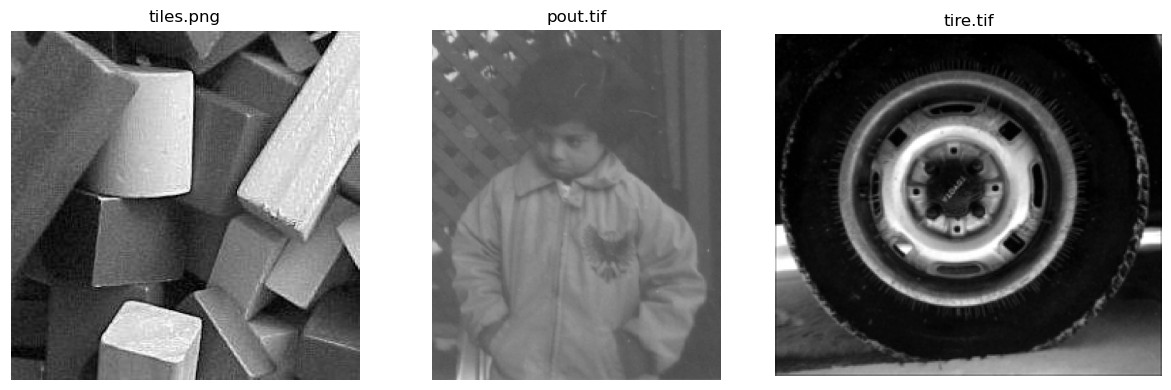

In [5]:
# EXERCISE 01 - Read and display the Week 3 test images.
# 1. Read tiles.png using cv2.imread(..., cv2.IMREAD_GRAYSCALE) and TILES_PATH.
# 2. Read pout.tif using POUT_PATH and store the result in pout.
# 3. Read tire.tif using TIRE_PATH and store the result in tire.
# 4. Check that each image is not None; if an image is None, check the working directory.
# 5. Use describe(...) to print shape, dtype, minimum, and maximum values.
# 6. Display all three images in a 1x3 Matplotlib figure using cmap='gray'.


tiles = cv2.imread(str(TILES_PATH), cv2.IMREAD_GRAYSCALE)
pout = cv2.imread(str(POUT_PATH), cv2.IMREAD_GRAYSCALE)
tire = cv2.imread(str(TIRE_PATH), cv2.IMREAD_GRAYSCALE)

for name, img in [('tiles', tiles), ('pout', pout), ('tire', tire)]:
    if img is None:
        raise FileNotFoundError(f'{name} could not be read. Check the working directory.')

describe('tiles', tiles)
describe('pout', pout)
describe('tire', tire)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, [tiles, pout, tire], ['tiles.png', 'pout.tif', 'tire.tif']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Brightness adjustment using addition and subtraction

Adding a positive constant increases brightness; subtracting a positive constant decreases brightness. OpenCV arithmetic functions such as `cv2.add` and `cv2.subtract` saturate values to the valid `uint8` range 0...255.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 02 - Brightness adjustment.
# 1. Create bright_tiles by adding 80 to tiles with cv2.add.
# 2. Create dark_tiles by subtracting 80 from tiles with cv2.subtract.
# 3. Display tiles, bright_tiles, and dark_tiles in one row.
# 4. Print image information for all three arrays using describe(...).


bright_tiles = cv2.add(tiles, 80)
dark_tiles = cv2.subtract(tiles, 80)

describe('tiles', tiles)
describe('bright_tiles', bright_tiles)
describe('dark_tiles', dark_tiles)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [tiles, bright_tiles, dark_tiles],
    ['tiles (original)', 'bright_tiles (+80)', 'dark_tiles (-80)'],
):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. NumPy overflow versus OpenCV saturation

Raw NumPy `uint8` arithmetic can wrap around modulo 256, while OpenCV arithmetic saturates to the valid display range. This distinction is important in point processing.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 03 - Compare NumPy overflow and OpenCV saturation.
# 1. Create a 1x1 uint8 image array p containing the value 250.
# 2. Add 20 using raw NumPy arithmetic and print the result (expect wrap-around).
# 3. Add 20 using cv2.add with a matching 1x1 uint8 array and print the result (expect saturation at 255).
# 4. Apply the same comparison to the tiles image by adding 120.
# 5. Display the NumPy result and OpenCV result side by side.


## 4. Multiplication, division, and affine transformations

A point transformation can be written as `y = alpha*x + beta`. `cv2.convertScaleAbs` is useful for practical scaling and offset operations.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 04 - Multiplication, division, and affine transform.
# 1. Use cv2.convertScaleAbs to create tiles_half with alpha=0.5, beta=0.
# 2. Create tiles_double with alpha=2.0, beta=0.
# 3. Create tiles_half_plus with alpha=0.5, beta=128.
# 4. Display original and transformed images in one row.


## 5. Complement and partial complement

The complement of an 8-bit grayscale image is `255 - x`. Partial complement operations only invert selected intensity ranges and can create solarization-like effects.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 05 - Complement and partial complement.
# 1. Create tiles_complement using cv2.bitwise_not(tiles).
# 2. Create partial_dark as a copy of tiles.
# 3. Build mask_dark for pixels whose value is <= 128.
# 4. Complement only the selected pixels in partial_dark.
# 5. Create partial_light by complementing only pixels whose value is >= 128.
# 6. Display original, complement, partial_dark, and partial_light.


## 6. Arithmetic operations between two images

Point arithmetic can also combine two images pixel by pixel. The two images must have the same size and compatible data types.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 06 - Arithmetic between two images.
# 1. Resize tiles and tire to 256x256 and store them as A and B.
# 2. Create add_img using cv2.add(A, B).
# 3. Create sub_img using cv2.subtract(A, B).
# 4. Create blend_img using cv2.addWeighted(A, 0.5, B, 0.5, 0).
# 5. Display A, B, add_img, sub_img, and blend_img.


## 7. Histogram of a grayscale image

A histogram counts how many pixels occur at each gray level. It helps us understand brightness, contrast, and intensity distribution.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 07 - Histogram of a grayscale image.
# 1. Use plot_histogram(tire, 'Histogram of tire.tif') and store the result as hist_tire.
# 2. Print the shape of hist_tire.
# 3. Print the sum of all histogram bins and compare it with tire.size.


## 8. Contrast stretching on pout.tif

Contrast stretching maps the minimum and maximum intensities of an image to a wider output range, commonly 0...255. In OpenCV, `cv2.normalize` can perform this operation.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 08 - Contrast stretching.
# 1. Use cv2.normalize to create pout_stretched from pout with output range 0 to 255.
# 2. Print the min and max values of pout and pout_stretched.
# 3. Display the original image and histogram, and stretched image and histogram in a 2x2 figure.


## 9. Manual contrast stretching formula

The same operation can be implemented directly using the formula: `(image - min) * 255 / (max - min)`. Floating-point arithmetic is used before converting back to `uint8`.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 09 - Manual contrast stretching formula.
# 1. Compute r_min and r_max from pout.
# 2. Apply the formula (pout - r_min) * 255 / (r_max - r_min) using float32 arithmetic.
# 3. Clip, round, and convert the result to uint8 as custom_stretched.
# 4. Compare custom_stretched with pout_stretched using np.array_equal.
# 5. Display custom_stretched.


## 10. Histogram equalization using OpenCV

Histogram equalization uses the cumulative distribution function of the histogram to redistribute gray levels. In OpenCV, grayscale histogram equalization is implemented by `cv2.equalizeHist`.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 10 - Histogram equalization using OpenCV.
# 1. Apply cv2.equalizeHist to pout and store the result as pout_equalized.
# 2. Display original pout image and histogram, and equalized image and histogram in a 2x2 figure.


## 11. Manual histogram equalization for a small matrix

This small example shows the mechanics of histogram equalization: histogram, cumulative distribution function, lookup table, and transformed image.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 11 - Manual histogram equalization for a small matrix.
# 1. Recreate the 4x4 small array with gray levels 0, 1, 2, and 3.
# 2. Set L = 4 and compute hist_small using np.bincount.
# 3. Compute cdf_small with cumulative sum.
# 4. Compute cdf_min as the first nonzero CDF value.
# 5. Build lut_small using the histogram equalization formula.
# 6. Apply the lookup table with small_equalized = lut_small[small].
# 7. Print the histogram, CDF, LUT, and equalized matrix.
# 8. Display original and equalized small matrices with the pixel values written on top.


## 12. Lookup tables with cv2.LUT

A lookup table stores the output value for every possible 8-bit input intensity. It is a fast way to implement point transformations.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 12 - Lookup tables with cv2.LUT.
# 1. Create x = np.arange(256, dtype=np.uint8).
# 2. Build three LUTs: lut_negative, lut_threshold, and lut_gamma.
# 3. Apply each LUT to the tire image using cv2.LUT.
# 4. Display original image and three transformed images.
# 5. Plot the three transformation curves.


## 13. Final comparison: stretching vs equalization

Compare contrast stretching and histogram equalization on the same low-contrast image. Write a short observation after inspecting the outputs.

**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.

In [ ]:
# EXERCISE 13 - Compare contrast stretching and histogram equalization.
# 1. Use pout as comparison_image.
# 2. Create comparison_stretched using cv2.normalize.
# 3. Create comparison_equalized using cv2.equalizeHist.
# 4. Display the three images and their histograms in a 2x3 figure.
# 5. Add a short print statement that explains the visual difference you observe.


## 14. Laboratory review and extension exercises

Before leaving the laboratory, make sure you can answer these questions:

1. What is a point operation, and why does it not need neighboring pixels?
2. Why is `cv2.add` safer than raw NumPy addition for many `uint8` images?
3. What visual effect do addition, subtraction, multiplication, and complement operations produce?
4. How does a histogram describe brightness and contrast?
5. What is the difference between contrast stretching and histogram equalization?
6. How does a cumulative distribution function become a histogram-equalization lookup table?
7. Why is `cv2.LUT` useful for point processing?

### Suggested extra work
- Repeat histogram equalization on `tire.tif` and `tiles.png`.
- Create lookup tables for gamma values 0.4, 0.8, 1.5, and 2.0.
- Try partial complementing pixels below 80, below 128, and above 180.
- Compare `cv2.equalizeHist` and CLAHE (`cv2.createCLAHE`) on `pout.tif`.


**Student task:** Complete the following code cell. Keep the requested variable names because later cells may use them.